# Phase 25: REES46 Scientific Audit (The Buyer Search)
====================================================
This notebook performs a **Rigor Audit** on the Model 2 (TCN) retrained on the 41-Million event REES46 dataset.

### Objectives:
1. **Minority-Class Evaluation**: Prove the model's ability to find buyers (Class 0) in a high-imbalance session stream.
2. **Scientific Lift**: Calculate the operational advantage of using this model over a random baseline.
3. **Model Confidence**: Analyze the Brier score and Calibration to ensure risk scores are reliable.
4. **0% Target Leakage Verification**: Confirm performance on a clean, session-stratified hold-out set.

In [6]:
import torch
import torch.nn as nn
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, brier_score_loss, accuracy_score
from torch.utils.data import DataLoader, TensorDataset

# Add scripts dir for architecture
sys.path.append(os.path.abspath("../scripts"))
from train_tcn import AbandonmentTCN

# Config
DATA_DIR = "../data/processed_rees46"
MODEL_PATH = "../tracker/models/tcn_rees46.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_PAGE_TYPES = 4
MAX_SEQ_LEN = 20

In [7]:
# 1. Load the TEST set (Hold-out)
print("Loading REES46 Test Data...")
X_page_te = np.load(os.path.join(DATA_DIR, "X_page_test.npy"))
X_dur_te = np.load(os.path.join(DATA_DIR, "X_dur_test.npy"))
y_te = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print(f"Test samples: {len(y_te):,}")
print(f"Abandonment rate in test set: {np.mean(y_te)*100:.2f}%")

Loading REES46 Test Data...
Test samples: 19,998
Abandonment rate in test set: 93.19%


In [8]:
# 2. Load Model
model = AbandonmentTCN(num_page_types=NUM_PAGE_TYPES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model successfully loaded.")

Model successfully loaded.


In [9]:
# 3. Run Inference
test_ds = TensorDataset(torch.from_numpy(X_page_te).long(), torch.from_numpy(X_dur_te).float())
test_loader = DataLoader(test_ds, batch_size=4096, shuffle=False)

all_probs = []
with torch.no_grad():
    for p, d in test_loader:
        p, d = p.to(DEVICE), d.to(DEVICE)
        logits = model(p, d).squeeze()
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())

y_probs_aband = np.array(all_probs)
y_labels_aband = y_te

# 4. Flip for Buyer Class (Class 0)
y_labels_buyer = (y_te == 0).astype(int)
y_probs_buyer = 1 - y_probs_aband

In [10]:
# 5. Calculate Scholar-Ready Metrics
prec_p, rec_p, _ = precision_recall_curve(y_labels_buyer, y_probs_buyer)
pr_auc_buyer = auc(rec_p, prec_p)
roc_auc_buyer = roc_auc_score(y_labels_buyer, y_probs_buyer)
brier = brier_score_loss(y_labels_aband, y_probs_aband)

# Operational Lift Analysis
baseline_rate = y_labels_buyer.mean()
n = len(y_probs_buyer)
k = max(int(n * 0.01), 1)  # Top 1%
top_k_idx = np.argsort(y_probs_buyer)[::-1][:k]
prec_at_1 = np.mean(y_labels_buyer[top_k_idx])
lift = prec_at_1 / baseline_rate if baseline_rate > 0 else 0

print("\n      SCIENTIFIC AUDIT: REES46 BUYER SEARCH")
print("="*45)
print(f"Baseline Buyer Rate:   {baseline_rate*100:.2f}%")
print(f"Buyer PR-AUC:          {pr_auc_buyer:.4f}")
print(f"Buyer ROC-AUC:         {roc_auc_buyer:.4f}")
print(f"Brier Score:           {brier:.4f}")
print("-"*45)
print(f"Precision @ Top 1%:     {prec_at_1*100:.2f}%")
print(f"SCIENTIFIC LIFT:        {lift:.2f}x")


      SCIENTIFIC AUDIT: REES46 BUYER SEARCH
Baseline Buyer Rate:   6.81%
Buyer PR-AUC:          0.4270
Buyer ROC-AUC:         0.7262
Brier Score:           0.0447
---------------------------------------------
Precision @ Top 1%:     77.39%
SCIENTIFIC LIFT:        11.37x


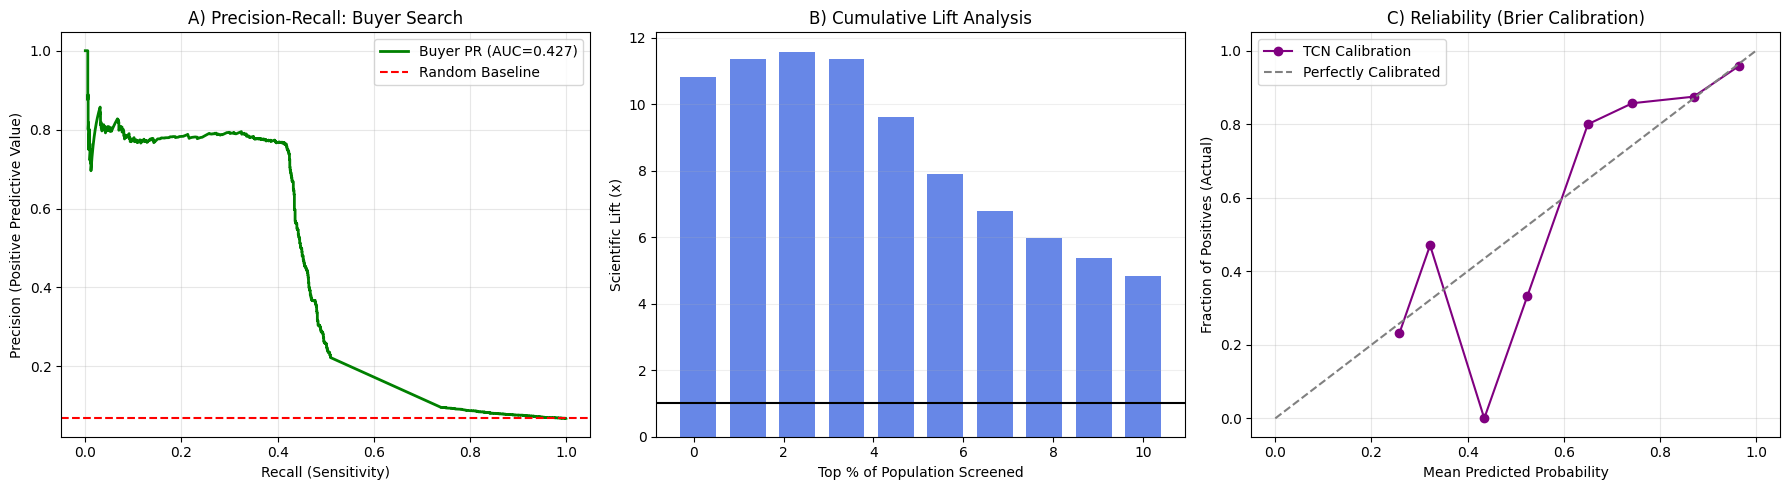

In [11]:
# 6. Visualizations
plt.figure(figsize=(18, 5))

# Panel A: PR Curve
plt.subplot(1, 3, 1)
plt.plot(rec_p, prec_p, label=f'Buyer PR (AUC={pr_auc_buyer:.3f})', color='green', lw=2)
plt.axhline(y=baseline_rate, color='red', linestyle='--', label='Random Baseline')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('A) Precision-Recall: Buyer Search')
plt.grid(alpha=0.3)
plt.legend()

# Panel B: Lift Chart
plt.subplot(1, 3, 2)
percentiles = np.linspace(0.1, 10, 10)
lifts = []
for p in percentiles:
    kp = max(int(n * p / 100), 1)
    tk_idx = np.argsort(y_probs_buyer)[::-1][:kp]
    lifts.append(np.mean(y_labels_buyer[tk_idx]) / baseline_rate)

plt.bar(percentiles, lifts, color='royalblue', alpha=0.8)
plt.xlabel('Top % of Population Screened')
plt.ylabel('Scientific Lift (x)')
plt.title('B) Cumulative Lift Analysis')
plt.axhline(y=1, color='black', linestyle='-')
plt.grid(alpha=0.2, axis='y')

# Panel C: Reliability Diagram (Calibration)
plt.subplot(1, 3, 3)
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_labels_aband, y_probs_aband, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='TCN Calibration', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('C) Reliability (Brier Calibration)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()